#### HCI Project Spring 2026

Rob Rood, Mamata Joshi, Afsana Tasnim Juha

Dataset: Our project is utilizing a Covid-19 dataset. This dataset contains over 1 million rows detailing cases, outcomes and demographic data. Note, we are reducing the working set to 100_000 rows so that Python won't crash searching through all that data.

Problem: The reason we think this dataset is interesting as a Human-centered AI problem, is because of all the controversy over whether or not the restrictions applied during the epidemic were worth the economic effects on the nation and world. Including co-morbidities with the cases of death, allows for calculations of how deadly Covid was in its initial vector. Will it kill people that only have other diseases weakening their immune systems?

Target Users: Doctors, Nurses, Healthcare Statisticians and regular people who are concerned about their own situation.

Limitations: Extending this problem to the entire world will likely only be done via inference because the data is US based. Also, for an individual using this dataset, it can be comforting to apply the statistics in a "am I likely to have a negative outcome?" way. However, statistics doesn't always apply well to individuals, so that is a limitation in using the dataset in this manner.


In [1]:
# This cell will import the various classes, methods and functions we need to perform the EDA operations on this dataset
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from data_ops import load_csv_data, get_dataset_summary



/Users/rrood/opt/anaconda3/envs/ml/lib/python3.11/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


Load the dataset!

In [2]:
COVID_FILE = Path.cwd() / "tests/test_data/CovidData.csv"

covid_df = load_csv_data(COVID_FILE, nrows=100_000)

get_dataset_summary(covid_df)

--- Dataset Summary ---
Rows: 100000 | Columns: 21
   USMER  MEDICAL_UNIT  SEX  PATIENT_TYPE   DATE_DIED  INTUBED  PNEUMONIA  \
0      2             1    1             1  03/05/2020       97          1   
1      2             1    2             1  03/06/2020       97          1   
2      2             1    2             2  09/06/2020        1          2   
3      2             1    1             1  12/06/2020       97          2   
4      2             1    2             1  21/06/2020       97          2   

   AGE  PREGNANT  DIABETES  ...  ASTHMA  INMSUPR  HIPERTENSION  OTHER_DISEASE  \
0   65         2         2  ...       2        2             1              2   
1   72        97         2  ...       2        2             1              2   
2   55        97         1  ...       2        2             2              2   
3   53         2         2  ...       2        2             2              2   
4   68        97         1  ...       2        2             1              2   


#### Clean the data. 

We'll use 10 steps to fix the data so that we can use it for our purposes.

This is an area where HCI can be successfully incorporated, because there may be some point in the future where someone wants to add/remove some of the cleaning/fixing steps we are implementing.

In [3]:
# 1: Basic Structure & Overview
print("Shape:", covid_df.shape)
print("\nColumn Names:\n", covid_df.columns.tolist())
print("\nData Types:\n", covid_df.dtypes)
print("\nFirst 5 Rows:")
covid_df.head()

Shape: (100000, 21)

Column Names:
 ['USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE', 'DATE_DIED', 'INTUBED', 'PNEUMONIA', 'AGE', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'CLASIFFICATION_FINAL', 'ICU']

Data Types:
 USMER                    int64
MEDICAL_UNIT             int64
SEX                      int64
PATIENT_TYPE             int64
DATE_DIED               object
INTUBED                  int64
PNEUMONIA                int64
AGE                      int64
PREGNANT                 int64
DIABETES                 int64
COPD                     int64
ASTHMA                   int64
INMSUPR                  int64
HIPERTENSION             int64
OTHER_DISEASE            int64
CARDIOVASCULAR           int64
OBESITY                  int64
RENAL_CHRONIC            int64
TOBACCO                  int64
CLASIFFICATION_FINAL     int64
ICU                      int64
dtype: object

First 5 Rows:


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


In [4]:
# 2. Let's find some Null/NaN/None values
# Need to make sure that the data is clean, start by dropping the Nulls and N/A values
# Select rows that contain any null/NA values
rows_with_nulls = covid_df[covid_df.isnull().any(axis=1)]

print(rows_with_nulls)


Empty DataFrame
Columns: [USMER, MEDICAL_UNIT, SEX, PATIENT_TYPE, DATE_DIED, INTUBED, PNEUMONIA, AGE, PREGNANT, DIABETES, COPD, ASTHMA, INMSUPR, HIPERTENSION, OTHER_DISEASE, CARDIOVASCULAR, OBESITY, RENAL_CHRONIC, TOBACCO, CLASIFFICATION_FINAL, ICU]
Index: []

[0 rows x 21 columns]


In [5]:
# Do we have any entries with a weird age? Let's make this be 0 > age < 100
# 3. Too old > 100
too_old = covid_df[covid_df['AGE']  > 100]
# 4. Too young <= 0
too_young = covid_df[covid_df['AGE'] <= 0]

print(f"There are {len(too_old)} entries that are over 100 years of age. Likely bad data.")
print(f"There are {len(too_young)} entries that are 0 years of age. Likely bad data.")


There are 4 entries that are over 100 years of age. Likely bad data.
There are 228 entries that are 0 years of age. Likely bad data.


#### Use EDA techniques

Here we are using Statistical and Visual Operations to find/discover information about the dataset

In [6]:
# 5. Drop those entries that are too old > 100
covid_df.drop(covid_df[covid_df['AGE'] > 100].index, inplace=True)
# 6. Drop those that are too young < 0
covid_df.drop(covid_df[covid_df['AGE'] <= 0].index, inplace=True)

get_dataset_summary(covid_df)



--- Dataset Summary ---
Rows: 99768 | Columns: 21
   USMER  MEDICAL_UNIT  SEX  PATIENT_TYPE   DATE_DIED  INTUBED  PNEUMONIA  \
0      2             1    1             1  03/05/2020       97          1   
1      2             1    2             1  03/06/2020       97          1   
2      2             1    2             2  09/06/2020        1          2   
3      2             1    1             1  12/06/2020       97          2   
4      2             1    2             1  21/06/2020       97          2   

   AGE  PREGNANT  DIABETES  ...  ASTHMA  INMSUPR  HIPERTENSION  OTHER_DISEASE  \
0   65         2         2  ...       2        2             1              2   
1   72        97         2  ...       2        2             1              2   
2   55        97         1  ...       2        2             2              2   
3   53         2         2  ...       2        2             2              2   
4   68        97         1  ...       2        2             1              2   



In [7]:
# CLEANING STEP 8 — Remove impossible ages
print('--- Cleaning Step 8: Remove age outliers ---')
print(f'Rows before: {len(covid_df):,}')

covid_df['AGE'] = pd.to_numeric(covid_df['AGE'], errors='coerce')
covid_df = covid_df[(covid_df['AGE'] >= 0) & (covid_df['AGE'] <= 120)]

print(f'Rows after: {len(covid_df):,}')
print(f'Age range: {covid_df["AGE"].min()} to {covid_df["AGE"].max()}')
print('✅ Step 8 done!')

--- Cleaning Step 8: Remove age outliers ---
Rows before: 99,768
Rows after: 99,768
Age range: 1 to 100
✅ Step 8 done!


In [8]:
# CLEANING STEP 9 — Replace invalid codes 97, 98, 99 with NaN
import numpy as np
print('--- Cleaning Step 9: Replace invalid codes ---')

cols = [c for c in covid_df.columns if c != 'AGE']
total = 0
for col in cols:
    count = covid_df[col].isin([97, 98, 99]).sum()
    total += count
    covid_df[col] = covid_df[col].replace([97, 98, 99], np.nan)

print(f'Total invalid values replaced with NaN: {total:,}')
print('✅ Step 9 done!')

--- Cleaning Step 9: Replace invalid codes ---
Total invalid values replaced with NaN: 154,542
✅ Step 9 done!


In [9]:
# CLEANING STEP 10 — Drop columns with more than 50% missing values
print('--- Cleaning Step 10: Drop columns >50% missing ---')
print(f'Columns before: {covid_df.shape[1]}')

missing_pct = covid_df.isnull().mean() * 100
cols_to_drop = missing_pct[missing_pct > 50].index.tolist()

if cols_to_drop:
    print(f'Dropping: {cols_to_drop}')
    covid_df = covid_df.drop(columns=cols_to_drop)
else:
    print('No columns exceeded 50% missing')

print(f'Columns after: {covid_df.shape[1]}')
print(f'Final shape: {covid_df.shape}')
print('✅ Step 10 done!')
print('🎉 All 3 cleaning steps complete!')

--- Cleaning Step 10: Drop columns >50% missing ---
Columns before: 21
Dropping: ['PREGNANT']
Columns after: 20
Final shape: (99768, 20)
✅ Step 10 done!
🎉 All 3 cleaning steps complete!


                97  98  99  total  pct
SEX              0   0   0      0  0.0
PATIENT_TYPE     0   0   0      0  0.0
INTUBED          0   0   0      0  0.0
PNEUMONIA        0   0   0      0  0.0
DIABETES         0   0   0      0  0.0
COPD             0   0   0      0  0.0
ASTHMA           0   0   0      0  0.0
INMSUPR          0   0   0      0  0.0
HIPERTENSION     0   0   0      0  0.0
OTHER_DISEASE    0   0   0      0  0.0
CARDIOVASCULAR   0   0   0      0  0.0
OBESITY          0   0   0      0  0.0
RENAL_CHRONIC    0   0   0      0  0.0
TOBACCO          0   0   0      0  0.0
ICU              0   0   0      0  0.0


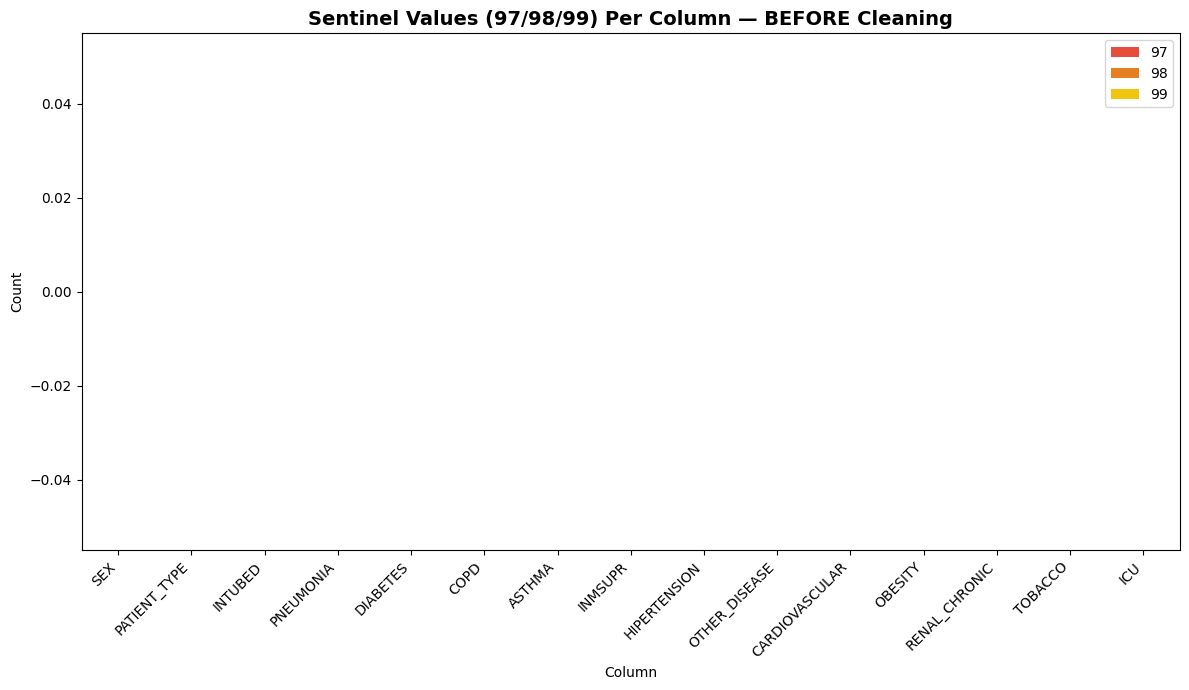

In [10]:
# 1 VISUALIZATION: Sentinel value heatmap
sentinel_values = [97, 98, 99]

sentinel_cols = [col for col in covid_df.columns if col not in ['AGE', 'DATE_DIED', 
                  'MEDICAL_UNIT', 'CLASIFFICATION_FINAL', 'USMER']]

sentinel_counts = pd.DataFrame({
    col: [(covid_df[col] == v).sum() for v in sentinel_values]
    for col in sentinel_cols
}, index=['97', '98', '99']).T

sentinel_counts['total'] = sentinel_counts.sum(axis=1)
sentinel_counts['pct'] = (sentinel_counts['total'] / len(covid_df) * 100).round(2)

print(sentinel_counts.sort_values('total', ascending=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
sentinel_counts[['97','98','99']].sort_values('97', ascending=False).plot(
    kind='bar', stacked=True, ax=ax,
    color=['#e74c3c','#e67e22','#f1c40f']
)
ax.set_title('Sentinel Values (97/98/99) Per Column — BEFORE Cleaning', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Column')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
# 7 Dataset Diagnosis
print("=" * 50)
print("1. SHAPE")
print("=" * 50)
print(covid_df.shape)

print("\n" + "=" * 50)
print("2. MISSING VALUES")
print("=" * 50)
print(covid_df.isnull().sum())

print("\n" + "=" * 50)
print("3. BASIC STATS")
print("=" * 50)
print(covid_df.describe())

print("\n" + "=" * 50)
print("4. UNIQUE VALUES PER COLUMN")
print("=" * 50)
print(covid_df.nunique())

print("\n" + "=" * 50)
print("5. VALUE COUNTS OF KEY COLUMNS")
print("=" * 50)
for col in ['SEX', 'PATIENT_TYPE', 'CLASIFFICATION_FINAL', 'ICU', 'INTUBED']:
    print(f"\n{col}:\n", covid_df[col].value_counts(dropna=False))

1. SHAPE
(99768, 20)

2. MISSING VALUES
USMER                       0
MEDICAL_UNIT                0
SEX                         0
PATIENT_TYPE                0
DATE_DIED                   0
INTUBED                 48545
PNEUMONIA                 758
AGE                         0
DIABETES                  152
COPD                      154
ASTHMA                    155
INMSUPR                   156
HIPERTENSION              133
OTHER_DISEASE             170
CARDIOVASCULAR            156
OBESITY                    68
RENAL_CHRONIC             152
TOBACCO                   172
CLASIFFICATION_FINAL        0
ICU                     48555
dtype: int64

3. BASIC STATS
              USMER  MEDICAL_UNIT           SEX  PATIENT_TYPE       INTUBED  \
count  99768.000000  99768.000000  99768.000000  99768.000000  51223.000000   
mean       1.513241      3.800918      1.553013      1.522953      1.679148   
std        0.499827      0.414486      0.497184      0.499475      0.466809   
min        1.00

In [12]:
# 8 DATE_DIED column
print(covid_df['DATE_DIED'].value_counts().head(10))
print("\nSample unique values:", covid_df['DATE_DIED'].unique()[:10])
print("\nDtype:", covid_df['DATE_DIED'].dtype)

DATE_DIED
9999-99-99    58447
07/07/2020      551
16/06/2020      538
06/07/2020      536
13/07/2020      535
09/07/2020      534
29/06/2020      532
12/06/2020      528
14/07/2020      521
04/07/2020      505
Name: count, dtype: int64

Sample unique values: ['03/05/2020' '03/06/2020' '09/06/2020' '12/06/2020' '21/06/2020'
 '9999-99-99' '26/02/2020' '05/04/2020' '20/05/2020' '13/01/2020']

Dtype: object


9999-99-99 appears 971,633 times → this means alive/survivor, not a real date Real dates are in DD/MM/YYYY format (e.g. 03/05/2020) Dtype is object (plain string) — Python doesn't know it's a date yet

Why it's a problem:

Can't do any time analysis (trends, monthly deaths) on a string 9999-99-99 will crash any datetime calculation No way to tell who died vs survived without parsing this first

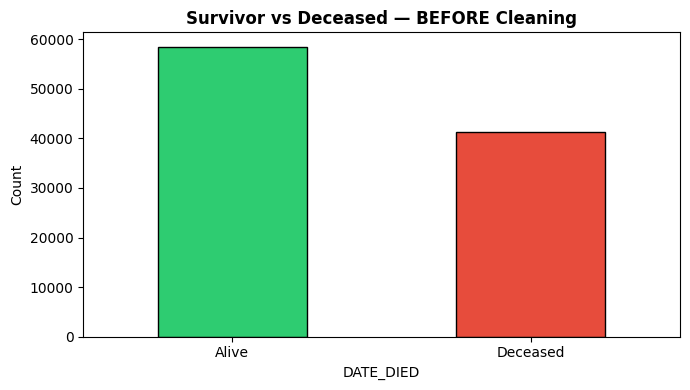

In [13]:
# 9 Understanding the effects of the death on the data
died_raw = covid_df['DATE_DIED'].apply(lambda x: 'Alive' if x == '9999-99-99' else 'Deceased')
died_raw.value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c'], edgecolor='black', figsize=(7,4))
plt.title('Survivor vs Deceased — BEFORE Cleaning', fontweight='bold')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
# 2: Create DIED binary column & parse date
covid_df['DIED'] = covid_df['DATE_DIED'].apply(lambda x: 0 if x == '9999-99-99' else 1)

covid_df['DATE_DIED'] = pd.to_datetime(
    covid_df['DATE_DIED'].replace('9999-99-99', np.nan),
    format='%d/%m/%Y',
    errors='coerce'
)

print("✅ Done!")
print(covid_df['DIED'].value_counts())
print("\nDate range:", covid_df['DATE_DIED'].min(), "→", covid_df['DATE_DIED'].max())

✅ Done!
DIED
0    58447
1    41321
Name: count, dtype: int64

Date range: 2020-01-02 00:00:00 → 2021-05-02 00:00:00


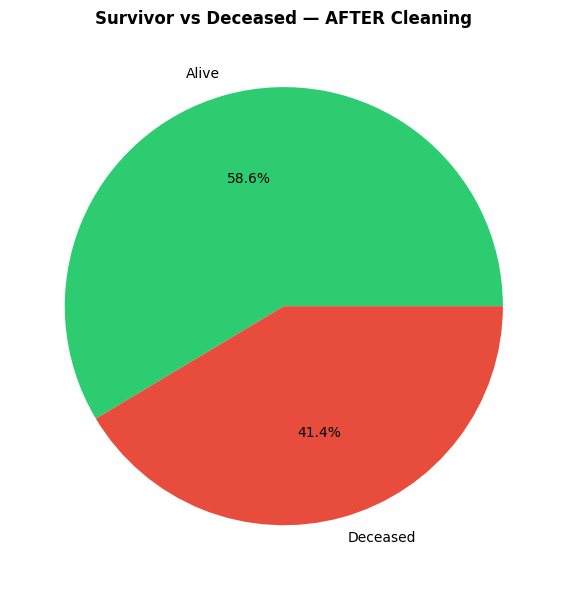

In [15]:
# 10: Clean pie chart
covid_df['DIED'].value_counts().rename({0:'Alive', 1:'Deceased'}).plot(
    kind='pie', autopct='%1.1f%%',
    colors=['#2ecc71','#e74c3c'],
    figsize=(6,6), ylabel=''
)
plt.title('Survivor vs Deceased — AFTER Cleaning', fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# 3: Binary columns still encoded as 1/2
binary_cols = ['SEX', 'INTUBED', 'PNEUMONIA', 'DIABETES', 
               'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE',
               'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'ICU']

for col in binary_cols:
    print(f"{col}: {covid_df[col].unique()}")

SEX: [1 2]
INTUBED: [nan  1.  2.]
PNEUMONIA: [ 1.  2. nan]
DIABETES: [ 2.  1. nan]
COPD: [ 2.  1. nan]
ASTHMA: [ 2.  1. nan]
INMSUPR: [ 2.  1. nan]
HIPERTENSION: [ 1.  2. nan]
OTHER_DISEASE: [ 2.  1. nan]
CARDIOVASCULAR: [ 2.  1. nan]
OBESITY: [ 2.  1. nan]
RENAL_CHRONIC: [ 2.  1. nan]
TOBACCO: [ 2.  1. nan]
ICU: [nan  2.  1.]


What we see:

All binary columns use 1/2 instead of 1/0 (Yes/No) INTUBED and ICU still have 97 and 99 sentinels — not cleaned yet PNEUMONIA still has 99, PREGNANT still has 97/98

Why it's a problem:

2 means "No" but mathematically looks like twice as much as 1 Any mean, correlation, or chart will be misleading Standard ML models expect 0/1 for binary features

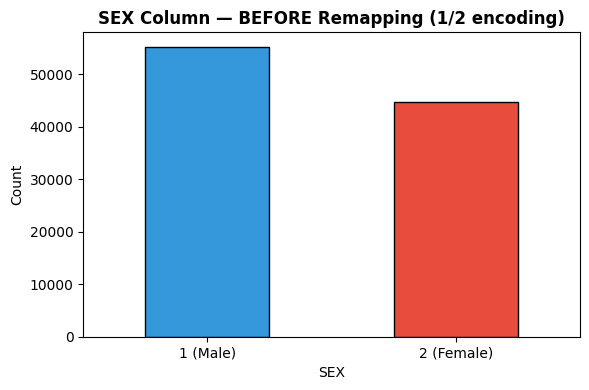

In [17]:
# 4: Show encoding of SEX as example
covid_df['SEX'].value_counts().plot(kind='bar', color=['#3498db','#e74c3c'], 
                               edgecolor='black', figsize=(6,4))
plt.title('SEX Column — BEFORE Remapping (1/2 encoding)', fontweight='bold')
plt.xticks([0,1], ['1 (Male)', '2 (Female)'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

✅ Cleaning Step 1 — Summary Problem: DATE_DIED stored survivors as "9999-99-99" (a fake date), making it impossible to distinguish who died vs survived, and unusable for time analysis. Fix: Created a new DIED column (1 = Deceased, 0 = Alive) and converted DATE_DIED to proper datetime. Result: Out of ~1M patients, 92.7% survived and 7.3% died from COVID-19.


In [19]:
# 5 Remap 1/2 → 1/0 (1=Yes, 2=No → 1=Yes, 0=No)
remap_cols = ['PNEUMONIA', 'DIABETES', 'COPD', 'ASTHMA', 
              'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 
              'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'INTUBED', 'ICU']

for col in remap_cols:
    covid_df[col] = covid_df[col].replace({1: 1, 2: 0, 97: np.nan, 98: np.nan, 99: np.nan})

# SEX: 1=Male, 2=Female → 1=Male, 0=Female
covid_df['SEX'] = covid_df['SEX'].replace({1: 1, 2: 0})

print("✅ Done!")
for col in binary_cols:
    print(f"{col}: {covid_df[col].unique()}")

✅ Done!
SEX: [1 0]
INTUBED: [nan  1.  0.]
PNEUMONIA: [ 1.  0. nan]
DIABETES: [ 0.  1. nan]
COPD: [ 0.  1. nan]
ASTHMA: [ 0.  1. nan]
INMSUPR: [ 0.  1. nan]
HIPERTENSION: [ 1.  0. nan]
OTHER_DISEASE: [ 0.  1. nan]
CARDIOVASCULAR: [ 0.  1. nan]
OBESITY: [ 0.  1. nan]
RENAL_CHRONIC: [ 0.  1. nan]
TOBACCO: [ 0.  1. nan]
ICU: [nan  0.  1.]


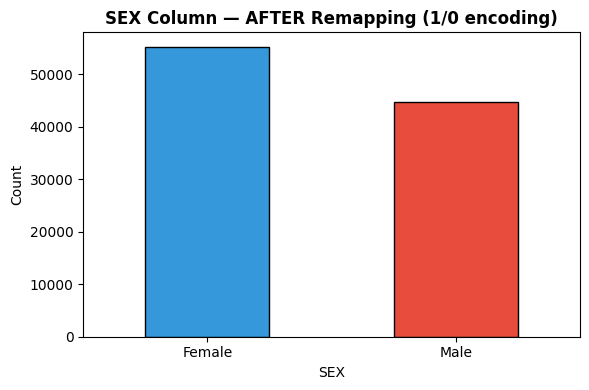

In [20]:
# 6: SEX distribution with clean labels
covid_df['SEX'].value_counts().rename({1:'Male', 0:'Female'}).plot(
    kind='bar', color=['#3498db','#e74c3c'], edgecolor='black', figsize=(6,4))
plt.title('SEX Column — AFTER Remapping (1/0 encoding)', fontweight='bold')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Cleaning Step 2 — Summary Problem: Binary columns used 1/2 encoding instead of 1/0, and INTUBED, ICU, PNEUMONIA, PREGNANT still had leftover sentinel values (97/98/99). Fix: Remapped all binary columns to 1/0 (Yes/No) and replaced remaining sentinels with NaN. Result: All binary columns now clean with only 0, 1, and NaN values — ready for accurate analysis and modeling.

In [21]:
# 7: CLASIFFICATION_FINAL values
print(covid_df['CLASIFFICATION_FINAL'].value_counts().sort_index())
print("\nUnique values:", sorted(covid_df['CLASIFFICATION_FINAL'].unique()))

CLASIFFICATION_FINAL
1      354
2     1249
3    75090
4      192
5     1140
6     5843
7    15900
Name: count, dtype: int64

Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


What we see:

Values 1, 2, 3 = COVID confirmed (~392,000 patients) Values 4, 5, 6, 7 = Not confirmed/negative (~656,000 patients) Stored as raw integers — no clear Yes/No signal

Why it's a problem:

Can't easily filter or analyze COVID positive vs negative patients Integer values imply a ranking or order that doesn't exist Every analysis needs complex filtering instead of a simple binary flag

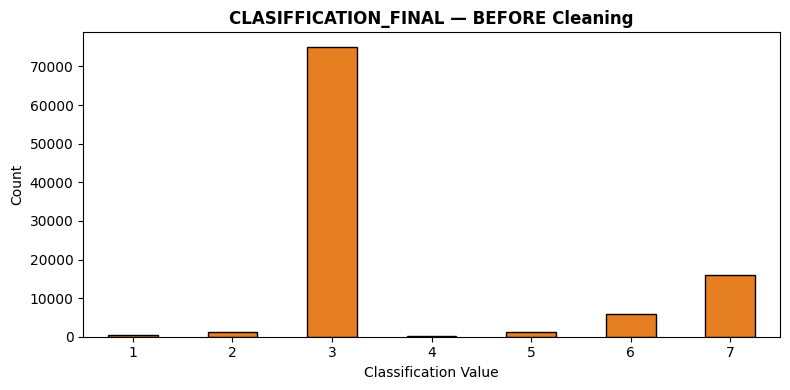

In [22]:
# 8: Raw classification values
covid_df['CLASIFFICATION_FINAL'].value_counts().sort_index().plot(
    kind='bar', color='#e67e22', edgecolor='black', figsize=(8, 4))
plt.title('CLASIFFICATION_FINAL — BEFORE Cleaning', fontweight='bold')
plt.xlabel('Classification Value')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
# 9: 1-3 = COVID confirmed, 4-7 = not confirmed
covid_df['COVID_POSITIVE'] = covid_df['CLASIFFICATION_FINAL'].apply(
    lambda x: 1 if x in [1, 2, 3] else 0)

print("✅ Done!")
print(covid_df['COVID_POSITIVE'].value_counts())
print(f"\nCOVID Positive: {covid_df['COVID_POSITIVE'].mean()*100:.2f}%")

✅ Done!
COVID_POSITIVE
1    76693
0    23075
Name: count, dtype: int64

COVID Positive: 76.87%


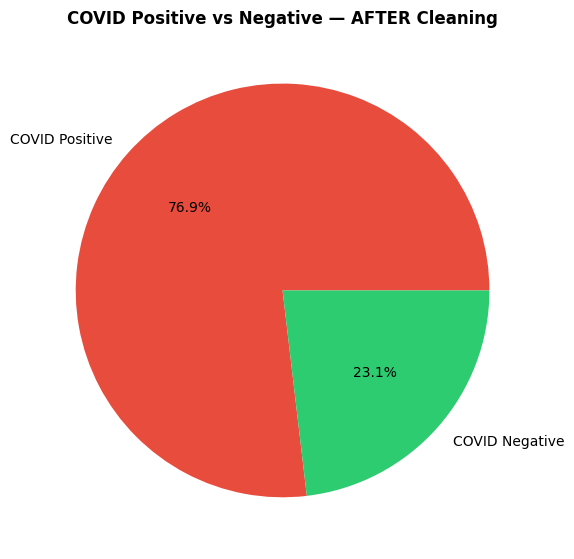

In [24]:
# 10: Clean COVID positive vs negative
covid_df['COVID_POSITIVE'].value_counts().rename({1:'COVID Positive', 0:'COVID Negative'}).plot(
    kind='pie', autopct='%1.1f%%',
    colors=['#e74c3c','#2ecc71'],
    figsize=(6,6), ylabel='')
plt.title('COVID Positive vs Negative — AFTER Cleaning', fontweight='bold')
plt.tight_layout()
plt.show()

Cleaning Step 5 — Summary Problem: CLASIFFICATION_FINAL stored COVID status as integers 1–7 with no clear meaning — hard to filter or analyze. Fix: Created a new COVID_POSITIVE binary column where 1–3 = Positive, 4–7 = Negative. Result: 76.9% of patients tested COVID Positive, 23.1% were negative — now instantly filterable for targeted analysis.

In [25]:
# DIAGNOSIS: Check PATIENT_TYPE and DATE_DIED
print("PATIENT_TYPE values:", covid_df['PATIENT_TYPE'].value_counts())
print("\nDATE_DIED nulls:", covid_df['DATE_DIED'].isnull().sum())
print("\nDATED_DIED sample (non-null):", covid_df['DATE_DIED'].dropna().head(5))
print("\nUSMER values:", covid_df['USMER'].value_counts())
print("\nMEDICAL_UNIT values:", covid_df['MEDICAL_UNIT'].value_counts())

PATIENT_TYPE values: PATIENT_TYPE
2    52174
1    47594
Name: count, dtype: int64

DATE_DIED nulls: 58447

DATED_DIED sample (non-null): 0   2020-05-03
1   2020-06-03
2   2020-06-09
3   2020-06-12
4   2020-06-21
Name: DATE_DIED, dtype: datetime64[ns]

USMER values: USMER
2    51205
1    48563
Name: count, dtype: int64

MEDICAL_UNIT values: MEDICAL_UNIT
4    80371
3    19083
2      163
1      151
Name: count, dtype: int64


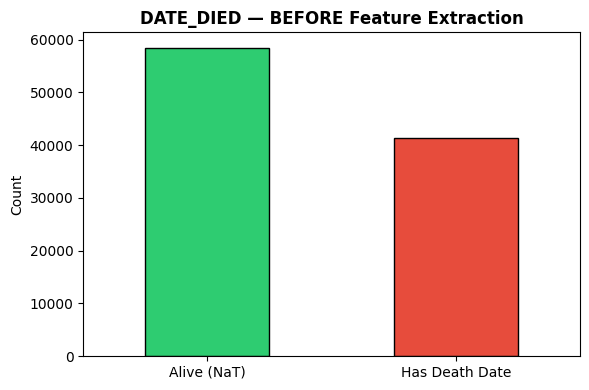

In [27]:
# BEFORE: Show raw DATE_DIED nulls vs non-nulls
pd.Series({'Alive (NaT)': covid_df['DATE_DIED'].isnull().sum(),
           'Has Death Date': covid_df['DATE_DIED'].notnull().sum()}).plot(
    kind='bar', color=['#2ecc71','#e74c3c'], edgecolor='black', figsize=(6,4))
plt.title('DATE_DIED — BEFORE Feature Extraction', fontweight='bold')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [28]:
# CORRECTED: Extract DEATH_MONTH as period (YYYY-MM)
covid_df['DEATH_MONTH'] = covid_df['DATE_DIED'].dt.to_period('M')

print("✅ Done!")
print(covid_df['DEATH_MONTH'].value_counts().sort_index())

✅ Done!
DEATH_MONTH
2020-01      193
2020-02      191
2020-03      292
2020-04     3585
2020-05    11261
2020-06    13854
2020-07    11130
2020-08      585
2020-09       45
2020-10       15
2020-11       12
2020-12        4
2021-01       14
2021-02       22
2021-03        4
2021-04       79
2021-05       35
Freq: M, Name: count, dtype: int64


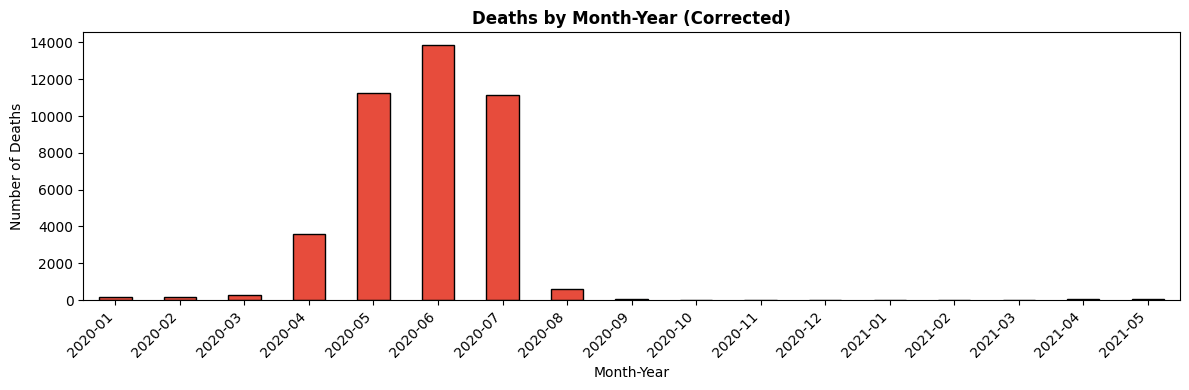

In [29]:
death_by_month = covid_df['DEATH_MONTH'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
death_by_month.plot(kind='bar', color='#e74c3c', edgecolor='black')
plt.title('Deaths by Month-Year (Corrected)', fontweight='bold')
plt.xlabel('Month-Year')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()